# Import required libraries


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Load dataset

In [128]:
# Load dataset
#df = pd.read_csv('/Users/human1/Documents/HFU/DSProject/LeadProject/LeadScoring.csv')
df = pd.read_csv('/Users/tzuching/Desktop/project/Lead Scoring.csv')

## 1.1: Basic structure


In [63]:
print("Shape of the DataFrame:", df.shape)
print("\nData Types:\n", df.dtypes)


Shape of the DataFrame: (9240, 37)

Data Types:
 Prospect ID                                       object
Lead Number                                        int64
Lead Origin                                       object
Lead Source                                       object
Do Not Email                                      object
Do Not Call                                       object
Converted                                          int64
TotalVisits                                      float64
Total Time Spent on Website                        int64
Page Views Per Visit                             float64
Last Activity                                     object
Country                                           object
Specialization                                    object
How did you hear about X Education                object
What is your current occupation                   object
What matters most to you in choosing a course     object
Search                                 

## 1.2: Head and tail


In [64]:
print("\nFirst 5 rows:\n")
df.tail(5)


First 5 rows:



,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
9235,19d6451e-fcd6-407c-b83b-48e1af805ea9,579564,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,...,No,Potential Lead,Mumbai,02.Medium,01.High,15.0,17.0,No,No,Email Marked Spam
9236,82a7005b-7196-4d56-95ce-a79f937a158d,579546,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,19.0,No,Yes,SMS Sent
9237,aac550fe-a586-452d-8d3c-f1b62c94e02c,579545,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,13.0,20.0,No,Yes,SMS Sent
9238,5330a7d1-2f2b-4df4-85d6-64ca2f6b95b9,579538,Landing Page Submission,Google,No,No,1,3.0,499,3.00,...,No,NaN,Other Metro Cities,02.Medium,02.Medium,15.0,16.0,No,No,SMS Sent
9239,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,579533,Landing Page Submission,Direct Traffic,No,No,1,6.0,1279,3.00,...,No,Potential Lead,Other Cities,02.Medium,01.High,15.0,18.0,No,Yes,Modified


In [65]:
print("\nLast 5 rows:\n")
df.tail(5)


Last 5 rows:



,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
9235,19d6451e-fcd6-407c-b83b-48e1af805ea9,579564,Landing Page Submission,Direct Traffic,Yes,No,1,8.0,1845,2.67,...,No,Potential Lead,Mumbai,02.Medium,01.High,15.0,17.0,No,No,Email Marked Spam
9236,82a7005b-7196-4d56-95ce-a79f937a158d,579546,Landing Page Submission,Direct Traffic,No,No,0,2.0,238,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,19.0,No,Yes,SMS Sent
9237,aac550fe-a586-452d-8d3c-f1b62c94e02c,579545,Landing Page Submission,Direct Traffic,Yes,No,0,2.0,199,2.00,...,No,Potential Lead,Mumbai,02.Medium,01.High,13.0,20.0,No,Yes,SMS Sent
9238,5330a7d1-2f2b-4df4-85d6-64ca2f6b95b9,579538,Landing Page Submission,Google,No,No,1,3.0,499,3.00,...,No,NaN,Other Metro Cities,02.Medium,02.Medium,15.0,16.0,No,No,SMS Sent
9239,571b5c8e-a5b2-4d57-8574-f2ffb06fdeff,579533,Landing Page Submission,Direct Traffic,No,No,1,6.0,1279,3.00,...,No,Potential Lead,Other Cities,02.Medium,01.High,15.0,18.0,No,Yes,Modified


## 1.3: Value counts (for each column if categorical or low unique count)

In [66]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(f"\n***Value counts for {col}:\n", df[col].value_counts())



***Value counts for Lead Origin:
 Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: Lead Origin, dtype: int64

***Value counts for Do Not Email:
 No     8506
Yes     734
Name: Do Not Email, dtype: int64

***Value counts for Do Not Call:
 No     9238
Yes       2
Name: Do Not Call, dtype: int64

***Value counts for Converted:
 0    5679
1    3561
Name: Converted, dtype: int64

***Value counts for Last Activity:
 Email Opened                    3437
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326
Email Link Clicked               267
Form Submitted on Website        116
Unreachable                       93
Unsubscribed                      61
Had a Phone Conversation          30
Approached upfront                 9
View in browser link Clic

## 1.4: Missing values


In [67]:
print("\nMissing Values Count:\n", df.isnull().sum())


Missing Values Count:
 Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
News

## 1.5: Check for any nulls

In [68]:
print("\nAny Nulls Present?\n", df.isnull().values.any())



Any Nulls Present?
 True


In [69]:
print("\nTotal Null values?\n", df.isnull().sum())



Total Null values?
 Prospect ID                                         0
Lead Number                                         0
Lead Origin                                         0
Lead Source                                        36
Do Not Email                                        0
Do Not Call                                         0
Converted                                           0
TotalVisits                                       137
Total Time Spent on Website                         0
Page Views Per Visit                              137
Last Activity                                     103
Country                                          2461
Specialization                                   1438
How did you hear about X Education               2207
What is your current occupation                  2690
What matters most to you in choosing a course    2709
Search                                              0
Magazine                                            0
Newspap

## 1.6: Duplicates

In [70]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


## 1.7: Sample of data


In [71]:
print("\nRandom Sample:\n")
df.sample(5)


Random Sample:



,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
7331,50bf7f2d-db59-4029-87f2-bfdce72f9aca,593169,Landing Page Submission,Google,No,No,0,3.0,358,3.0,...,No,Select,Other Cities of Maharashtra,02.Medium,01.High,14.0,17.0,No,No,Email Opened
3248,f521a170-326f-4ca7-a0b3-1483dc4394a3,628916,Landing Page Submission,Direct Traffic,No,No,1,2.0,1844,2.0,...,No,Select,Mumbai,NaN,NaN,NaN,NaN,No,Yes,SMS Sent
1183,cb6f9128-d9a5-4fa5-9e08-0df8e482c7d6,647539,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Other Leads,Select,02.Medium,02.Medium,15.0,14.0,No,No,Modified
4418,3fd8c2ee-1d45-4a24-aa79-752a1781105d,617368,Landing Page Submission,Google,No,No,0,4.0,1501,4.0,...,No,Select,Mumbai,NaN,NaN,NaN,NaN,No,No,SMS Sent
4562,2e553d81-705a-4688-94aa-23e0d0df31ba,615988,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,NaN,NaN,NaN,NaN,NaN,NaN,No,No,Email Opened


## 1.8: Info

In [72]:
print('\nData Information\n')
df.info()


Data Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit             

# SECTION 2: DATA VISUALIZATION

## 2.1: Numerical Features

### 2.1.1: Histograms

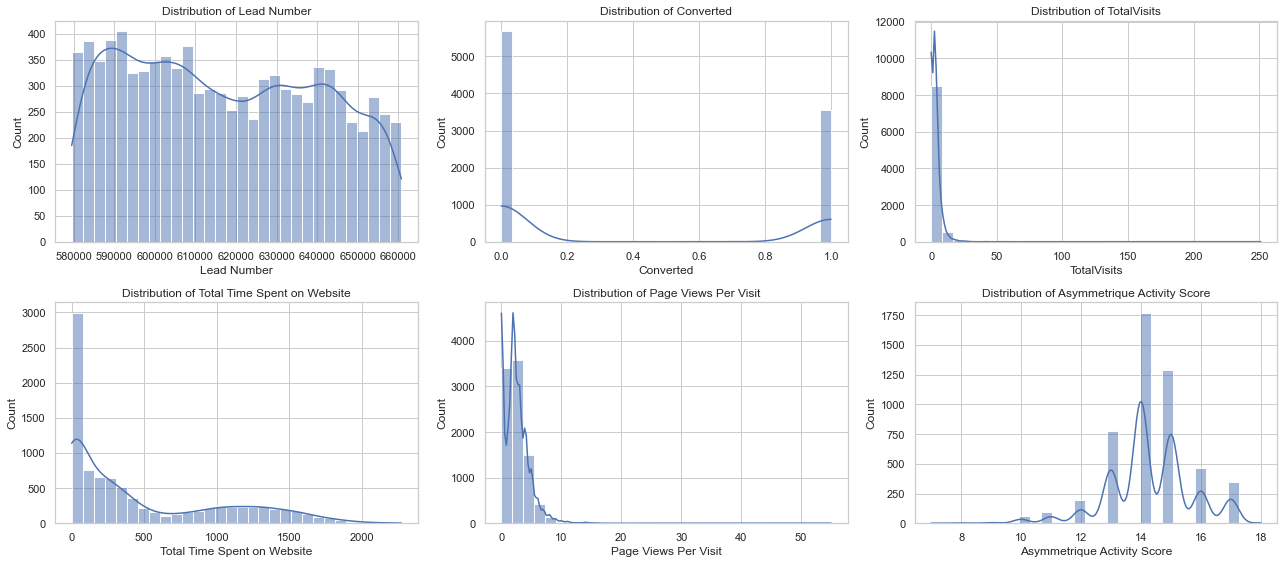

In [73]:
def plot_histograms(df, max_plots=6):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import math

    sns.set(style="whitegrid")
    numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    num_cols = numerical[:max_plots]
    rows = math.ceil(len(num_cols) / 3)

    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
    for i, col in enumerate(num_cols):
        ax = axes[i // 3, i % 3]
        sns.histplot(df[col].dropna(), kde=True, bins=30, ax=ax)
        ax.set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
plot_histograms(df)

### 2.1.2: Boxplots

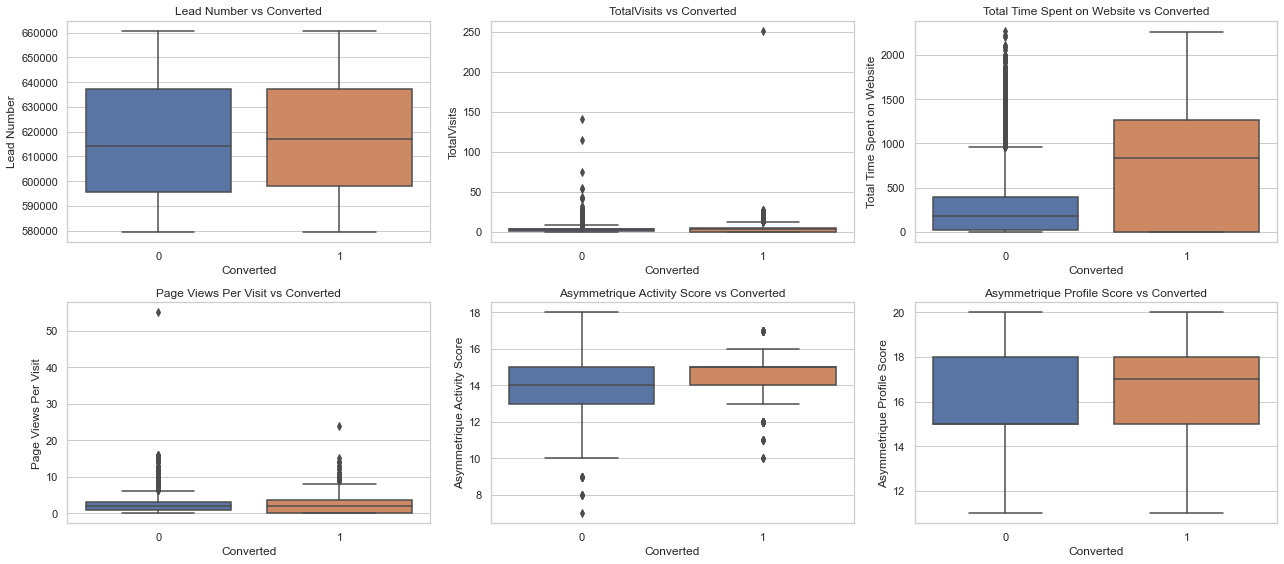

In [74]:
def plot_boxplots(df, target_col='Converted', max_plots=6):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import math

    sns.set(style="whitegrid")
    numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if target_col in numerical:
        numerical.remove(target_col)
    num_cols = numerical[:max_plots]
    rows = math.ceil(len(num_cols) / 3)

    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
    for i, col in enumerate(num_cols):
        ax = axes[i // 3, i % 3]
        sns.boxplot(x=target_col, y=col, data=df, ax=ax)
        ax.set_title(f'{col} vs {target_col}')
    plt.tight_layout()
    plt.show()
plot_boxplots(df)

### 2.1.3: Heatmap

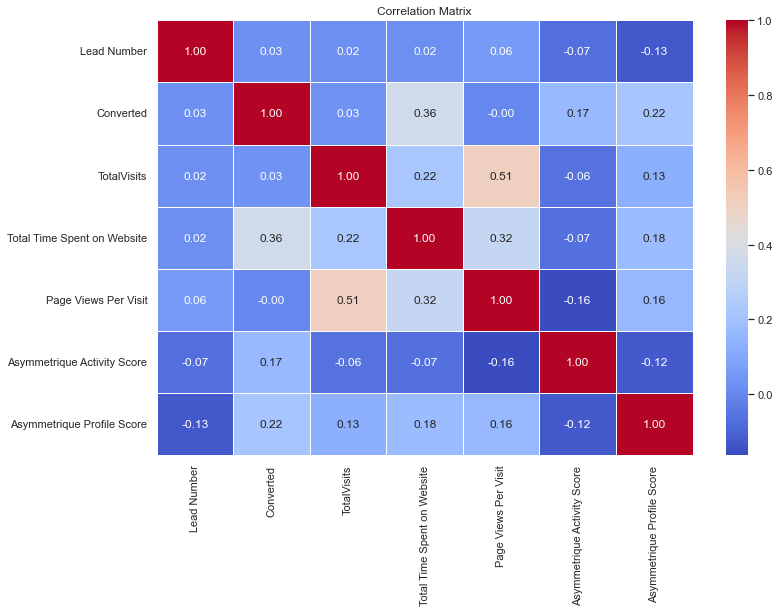

In [75]:
def plot_correlation_heatmap(df):
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 8))
    corr = df.select_dtypes(include='number').corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.show()
plot_correlation_heatmap(df)

### 2.1.4: Scatterplot

📈 Scatter Plots against `Converted`


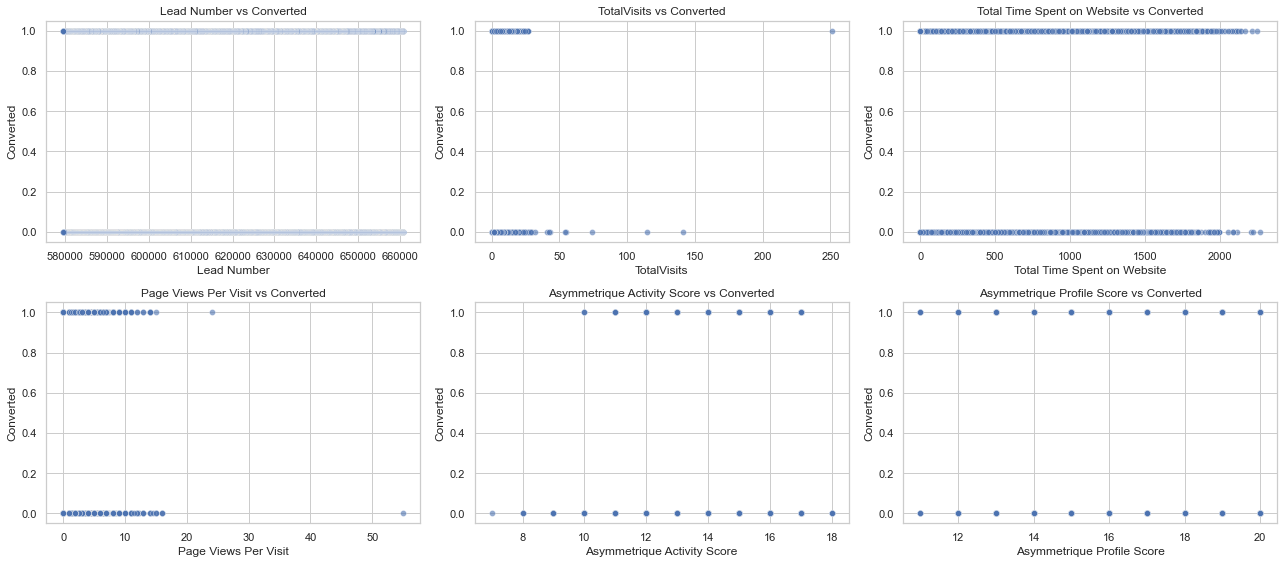

In [76]:
def plot_scatterplots(df, target_col='Converted', max_plots=6):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import math

    sns.set(style="whitegrid")

    # Filter numeric features except the target
    numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if target_col in numerical:
        numerical.remove(target_col)

    num_cols = numerical[:max_plots]
    rows = math.ceil(len(num_cols) / 3)

    print(f"📈 Scatter Plots against `{target_col}`")
    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))

    for i, col in enumerate(num_cols):
        ax = axes[i // 3, i % 3]
        sns.scatterplot(data=df, x=col, y=target_col, alpha=0.6, ax=ax)
        ax.set_title(f'{col} vs {target_col}')
    
    plt.tight_layout()
    plt.show()
plot_scatterplots(df)

## 2.2: Categorical Features

### 2.2.1: Barplot

### 2.2.2: Histograms

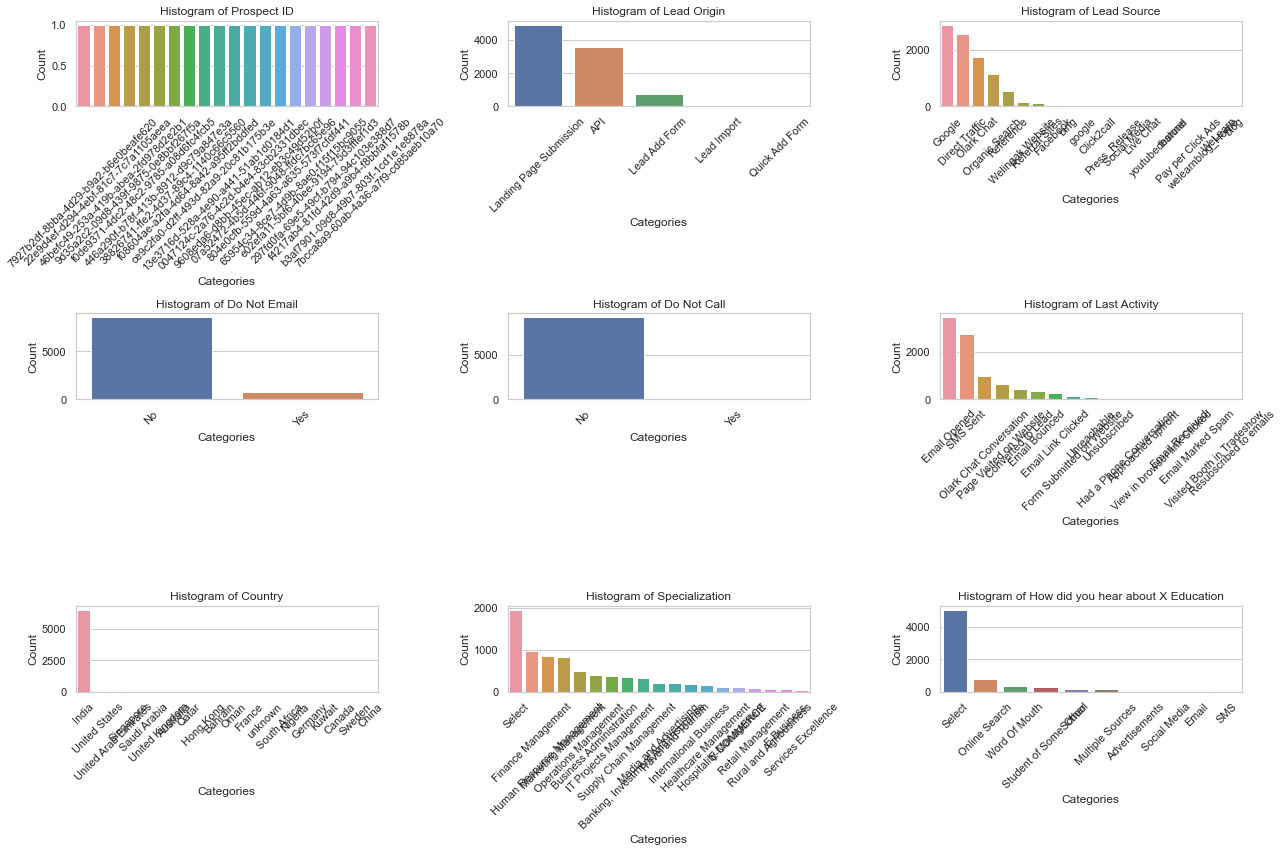

In [77]:
def plot_categorical_histograms(df, max_plots=9):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import math

    sns.set(style="whitegrid")
    
    
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    cols = cat_cols[:max_plots]
    rows = math.ceil(len(cols) / 3)

    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        try:
            value_counts = df[col].value_counts().nlargest(20)  # top 20 for readability
            sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i])
            axes[i].set_title(f'Histogram of {col}')
            axes[i].set_ylabel("Count")
            axes[i].set_xlabel("Categories")
            axes[i].tick_params(axis='x', rotation=45)
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error plotting {col}\n{str(e)}', ha='center')
            axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
plot_categorical_histograms(df)

# SECTION 3: DATA PREPARATION


## 3.1: Univariate Analysis

In [78]:
num_cols = df.select_dtypes(include=np.number).columns

print("\nUnivariate Analysis:\n")
df[num_cols].describe()



Univariate Analysis:



,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


## 3.2: Binary Data Analysis

In [79]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
print("Binary Features:", binary_cols)

# Define the encoding dictionary
activity_index_map = {
    '01.High': 3,
    '02.Medium': 2,
    '03.Low': 1
}

# Apply the encoding
df['Asymmetrique Activity Index'] = df['Asymmetrique Activity Index'].map(activity_index_map)
df['Asymmetrique Profile Index'] = df['Asymmetrique Profile Index'].map(activity_index_map)


binary_cats = ['Do Not Email','Do Not Call','Search','Magazine','Newspaper Article',
               'X Education Forums','Newspaper','Digital Advertisement','Through Recommendations',
               'Receive More Updates About Our Courses', 'Update me on Supply Chain Content','Get updates on DM Content',
               'I agree to pay the amount through cheque', 'A free copy of Mastering The Interview']

null_values = df[binary_cats].isnull().sum()
total = df[binary_cats].count()
yes_no = df[binary_cats].applymap(lambda x: 1 if x == 'Yes' or x == 'No' else 0).sum()
df_binary_cats = pd.DataFrame({'total': total,
                               'null_%': null_values/total*100,
                               'yes/no_%': yes_no/total*100})
df_binary_cats

Binary Features: ['Do Not Email', 'Do Not Call', 'Converted', 'Search', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'A free copy of Mastering The Interview']


,total,null_%,yes/no_%
Do Not Email,9240,0.0,100.0
Do Not Call,9240,0.0,100.0
Search,9240,0.0,100.0
Magazine,9240,0.0,100.0
Newspaper Article,9240,0.0,100.0
X Education Forums,9240,0.0,100.0
Newspaper,9240,0.0,100.0
Digital Advertisement,9240,0.0,100.0
Through Recommendations,9240,0.0,100.0
Receive More Updates About Our Courses,9240,0.0,100.0


## 3.3: Value Count Analysis

In [80]:
from sklearn.preprocessing import FunctionTransformer

def data_cleaning(df):
    df = df.copy()
    
    # Drop ID columns if they exist
    for col in ['Prospect ID', 'Lead Number']:
        if col in df.columns:
            df = df.drop(col, axis=1)
    
    # Define binary categorical columns - make sure this list is defined before
    # e.g. binary_cats = ['some_binary_col1', 'some_binary_col2']
    if 'binary_cats' in globals():
        for col in binary_cats:
            if col in df.columns:
                df[col] = df[col].map(lambda x: 0 if x == 'No' else 1)
    
    # Rename columns for easier handling
    df.columns = df.columns.str.replace(' ', '_').str.lower()
    
    return df

# Wrap the function as transformer
initial_clean = FunctionTransformer(data_cleaning)

# Example of usage:
df_clean = initial_clean.fit_transform(df)

In [81]:
def value_counts_feature(df):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        print(df[col].value_counts())
        print('***')
value_counts_feature(df_clean)   

Landing Page Submission    4886
API                        3580
Lead Add Form               718
Lead Import                  55
Quick Add Form                1
Name: lead_origin, dtype: int64
***
Google               2868
Direct Traffic       2543
Olark Chat           1755
Organic Search       1154
Reference             534
Welingak Website      142
Referral Sites        125
Facebook               55
bing                    6
google                  5
Click2call              4
Press_Release           2
Social Media            2
Live Chat               2
youtubechannel          1
testone                 1
Pay per Click Ads       1
welearnblog_Home        1
WeLearn                 1
blog                    1
NC_EDM                  1
Name: lead_source, dtype: int64
***
Email Opened                    3437
SMS Sent                        2745
Olark Chat Conversation          973
Page Visited on Website          640
Converted to Lead                428
Email Bounced                    326


## 3.4: Missing Value Analysis

In [82]:
### Explore missing values

import seaborn as sns
import matplotlib.pyplot as plt
df_ = df_clean.copy()

# Set style for better visualizations
train_eda = train.copy()
sns.set_style('dark')
sns.set(rc={'axes.grid':False})
sns.set_palette('viridis')

null_ = pd.DataFrame()
null_['proportion'] = np.round(df_clean.isnull().sum()/len(df_clean),4) * 100
null_['amount'] = df_clean.isnull().sum()

# Show only those columns with at least 1 missing value
null_.sort_values(by='proportion', ascending=False)[null_.amount >= 0]

NameError: name 'train' is not defined

In [83]:
def barplot_catcols(column,width,heigh):
  """Plot conversion rate"""
  fig, ax  = plt.subplots(figsize=(width,heigh))
  ax = sns.barplot(data=df_.fillna('NaN'), x='converted', y=column,
            order=order(df_.fillna('NaN'),column),
            orient='h', palette='viridis',
            seed=2)
  plt.title(f'Conversion Rate by {column.replace("_"," ").title()}', loc='left', size=18)
  return ax

def order(df,x,y=None):
    if y is not None:
        return df.groupby(x)[y].mean().sort_values(ascending=False).index
    else:
        return df.groupby(x)['converted'].mean().sort_values(ascending=False).index

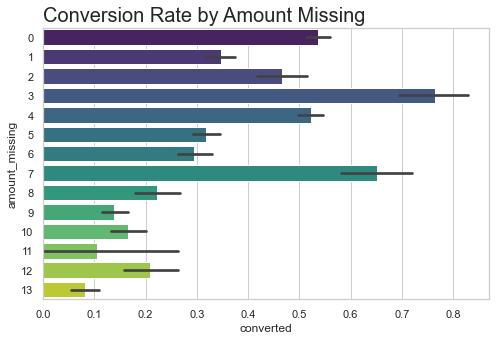

In [84]:
# Number of missing values in each row
df_['amount_missing'] = df_.isnull().sum(1)

# Plot the relation between amount missing and conversion rate
fig, ax  = plt.subplots(figsize=(8,5))
ax = sns.barplot(data=df_.fillna('NaN'), x='converted', y='amount_missing',
            orient='h', palette='viridis',
            seed=2)
plt.title(f'Conversion Rate by Amount Missing', loc='left', size=20)
plt.show()

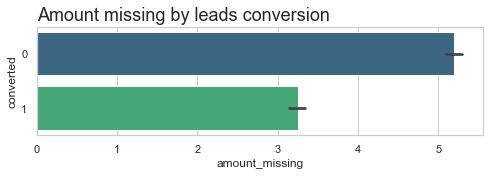

In [85]:
fig, ax  = plt.subplots(figsize=(8,2))
ax = sns.barplot(data=df_, x='amount_missing', y='converted',
            orient='h', palette=sns.color_palette('viridis',2),
            seed=2)
plt.title(f'Amount missing by leads conversion', loc='left', size=18)
plt.show()


## 3.4: Correlation with target variable

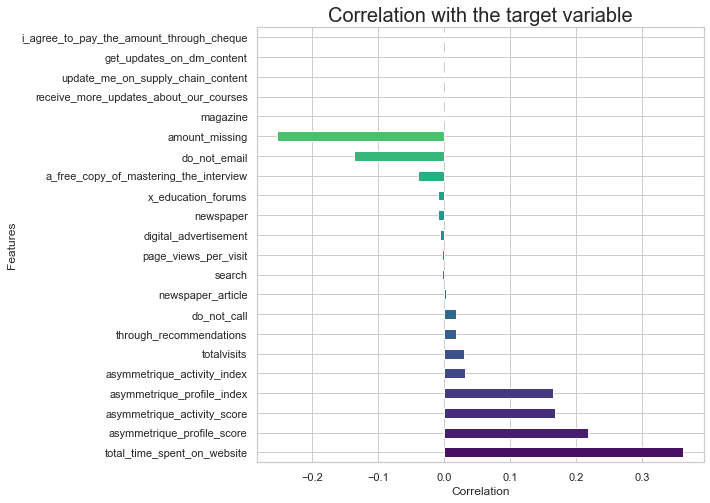

In [86]:
correlations = df_.select_dtypes('number').corr()['converted'].sort_values(ascending=False)

plt.figure(figsize=(8, 8))
correlations[1:].plot(kind='barh', 
                 color=sns.color_palette('viridis', len(correlations)))

plt.title('Correlation with the target variable', fontsize=20)
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.show()

### 3.4.1: Insights of Data

There's a negative correlation between missing lead data and the conversion rate. Higher instances of missing data might signify incomplete or poorly managed lead information, leading to potential difficulties in accurately categorizing and nurturing leads.

Notably, there's one column, **"Total Time Spent On Website,"** which has a stronger correlation with the target variable than the number of missing values columns. This suggests that it might be a better potential predictor than most of the other features.


In [87]:
print(f'Duplicate rows from original dataset: {df.duplicated().sum()}')
print(f'Duplicate rows after feature engineer: {df_clean.duplicated().sum()}')


Duplicate rows from original dataset: 0
Duplicate rows after feature engineer: 1281


## 3.5: Target Variable Analysis

In [88]:
import plotly.graph_objects as go

# Count data
count = df_['converted'].value_counts()

# Create a 3D-like pie chart (donut style)
fig = go.Figure(go.Pie(
    labels=count.index,
    values=count.values,
    hole=0.5,  # Makes it a donut
    marker=dict(colors=['#29568CFF', '#3CBB75FF']),
    hoverinfo='label+percent+value',
    textinfo='percent',
    textfont_size=18
))

fig.update_layout(
    title_text='Converted',
    title_font_size=24,
    showlegend=True,
    margin=dict(t=50, b=50, l=50, r=50)
)

# Show the chart
fig.show()


/opt/anaconda3/lib/python3.9/site-packages/plotly/io/_renderers.py:55: UserWarning:

Plotly version >= 6 requires Jupyter Notebook >= 7 but you have 6.4.5 installed.
 To upgrade Jupyter Notebook, please run `pip install notebook --upgrade`.



## 3.6: Comparison of Feature with Conversion Rate

### 3.6.1: Conversion Rate by Lead Profile

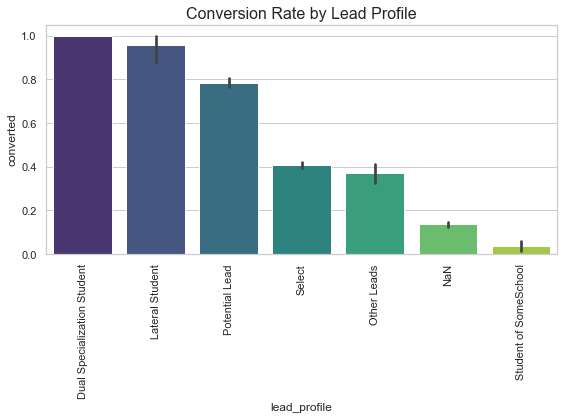

In [89]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df_.fillna('NaN'), x='lead_profile', y='converted',
            palette='viridis', order=order(df_.fillna('NaN'),'lead_profile'),
            seed=2)

plt.xticks(rotation=90)
plt.title(f'Conversion Rate by Lead Profile', loc='center', size=16)

plt.tight_layout()
plt.show()

In [90]:
#Lead Activity

In [91]:
activity_columns = ['totalvisits','total_time_spent_on_website','page_views_per_visit']

df_[activity_columns].corr().style.background_gradient(cmap='vlag_r')

,totalvisits,total_time_spent_on_website,page_views_per_visit
totalvisits,1.000000,0.221240,0.512125
total_time_spent_on_website,0.221240,1.000000,0.320361
page_views_per_visit,0.512125,0.320361,1.000000


### 3.6.2: Conversion Rate by Last Activity and Last Notable Activity

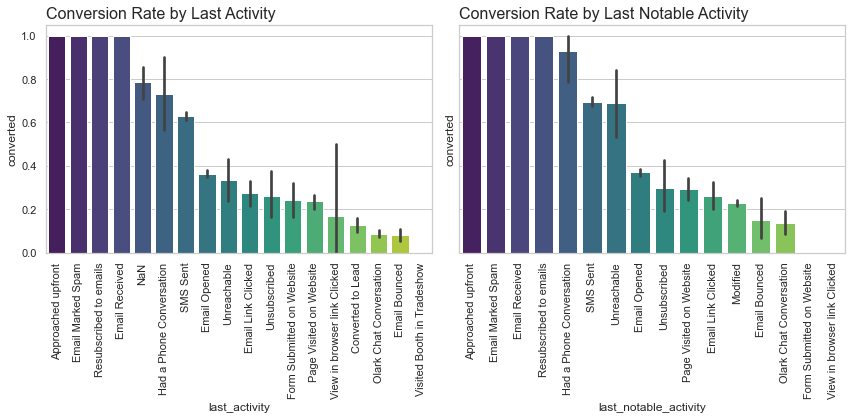

In [92]:
fig, ax  = plt.subplots(1,2, figsize=(12,6), sharey=True)

sns.barplot(data=df_.fillna('NaN'), x='last_activity', y='converted',
            order=order(df_.fillna('NaN'),'last_activity'),
            palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title(f'Conversion Rate by Last Activity', loc='left', size=16)

sns.barplot(data=df_.fillna('NaN'), x='last_notable_activity', y='converted',
                  order=order(df_.fillna('NaN'),'last_notable_activity'),
                  palette='viridis', seed=2)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_title(f'Conversion Rate by Last Notable Activity', loc='left', size=16)

plt.tight_layout()
plt.show()

### 3.6.3: Conversion Rate by Lead Quality

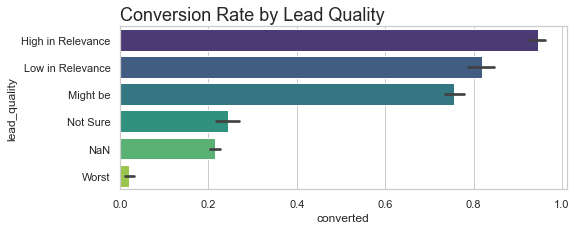

<Figure size 432x288 with 0 Axes>

In [93]:
barplot_catcols('lead_quality',8,3)
plt.show()
plt.savefig('lead_quality.png')


### 3.6.4: Conversion Type by Tags

FileNotFoundError: [Errno 2] No such file or directory: '/Users/human1/Documents/HFU/DSResources/tags.png'

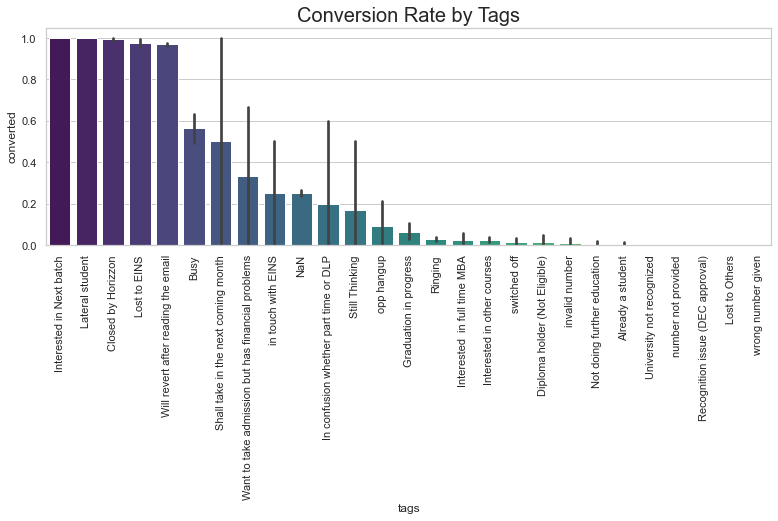

In [94]:
fig, ax  = plt.subplots(figsize=(13,4))

sns.barplot(data=df_.fillna('NaN'), x='tags', y='converted',
            order=order(df_.fillna('NaN'),'tags'),
            palette='viridis',
            seed=2)
plt.xticks(rotation=90)
plt.title(f'Conversion Rate by Tags', loc='center', size=20)
plt.savefig('/Users/human1/Documents/HFU/DSResources/tags.png', bbox_inches='tight')

plt.show()


### 3.6.5: Conversion Type by Specilization and Occupation

In [ ]:
fig, ax  = plt.subplots(1,2, figsize=(14,7), sharey=True)

sns.barplot(data=df_.fillna('NaN'), x='specialization', y='converted',
            order=order(df_.fillna('NaN'),'specialization'),
            palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title(f'Conversion Rate by Specialization', loc='left', size=16)

sns.barplot(data=df_.fillna('NaN'), x='what_is_your_current_occupation', y='converted',
                  order=order(df_.fillna('NaN'),'what_is_your_current_occupation'),
                  palette='viridis', seed=2)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_title(f'Conversion Rate by Occupation', loc='left', size=16)

plt.tight_layout()
plt.savefig('/Users/human1/Documents/HFU/DSResources/specialization_occupation.png', bbox_inches='tight')

plt.show()

### 3.6.4: Conversion Type by Tags

In [ ]:
conversion_country = df_.groupby('country')['converted'].mean()
country_count = df_['country'].value_counts().sort_index()
country_count

### 3.6.5: Conversion Type by Country

In [95]:
import plotly.graph_objects as go


fig = go.Figure(data=go.Choropleth(
    locations=conversion_country.index,
    locationmode='country names',
    z=conversion_country.values,
    text=country_count.values,
    colorscale='deep', 
    colorbar_title='Conversion Rate',
    hovertemplate='%{location}<br>Conversion: %{z:.2f}<br>Count: %{text}',
))

fig.update_geos(projection_type="mercator")

fig.update_layout(
    width=1000,   # in pixels
    height=800,

    title='Conversion Rate by Country',
    geo=dict(showcoastlines=True),
    font=dict(size=16),
)



fig.show()

NameError: name 'conversion_country' is not defined

### 3.6.6: Conversion Type by City

FileNotFoundError: [Errno 2] No such file or directory: '/Users/human1/Documents/HFU/DSResources/city.png'

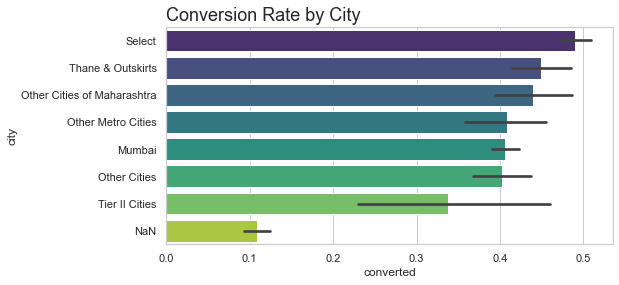

In [96]:
barplot_catcols('city',8,4)
plt.savefig('/Users/human1/Documents/HFU/DSResources/city.png', bbox_inches='tight')


plt.show()


In [ ]:
print("Cities where country isn't India:")
df_[df_['country'] != 'India'].city.value_counts(dropna=False)

In [97]:
print('Countries where City as equal to an Indian city:')
indian_cities = ['Mumbai','Thane & Outskirts','Other Cities of Maharashtra','Tier II Cities']
df_[df_.city.isin(indian_cities)].country.value_counts(dropna=False)

Countries where City as equal to an Indian city:


India                   4029
NaN                      336
United States             41
United Arab Emirates      21
United Kingdom            11
Singapore                 11
Saudi Arabia              10
Australia                  9
Bahrain                    5
Qatar                      5
Hong Kong                  4
Canada                     3
Germany                    3
Belgium                    2
France                     2
Oman                       2
Kuwait                     2
Netherlands                2
China                      1
Sweden                     1
Malaysia                   1
Switzerland                1
Philippines                1
Vietnam                    1
Indonesia                  1
Name: country, dtype: int64

1️⃣ Fix City-Country Mismatch:
Update the country to “India” for cities:

Mumbai

Thane & Outskirts

Other Cities of Maharashtra

Tier II Cities

2️⃣ Group Rare Countries:
Keep top 5 countries; group the rest as “Other”.

3️⃣ Handle Missing City Data:
Flag rows with missing city values due to lower conversion rates.`

### 3.6.7: Conversion Type by Lead Source & How did you hear about us?

FileNotFoundError: [Errno 2] No such file or directory: '/Users/human1/Documents/HFU/DSResources/lead_source&hear_about_us.png'

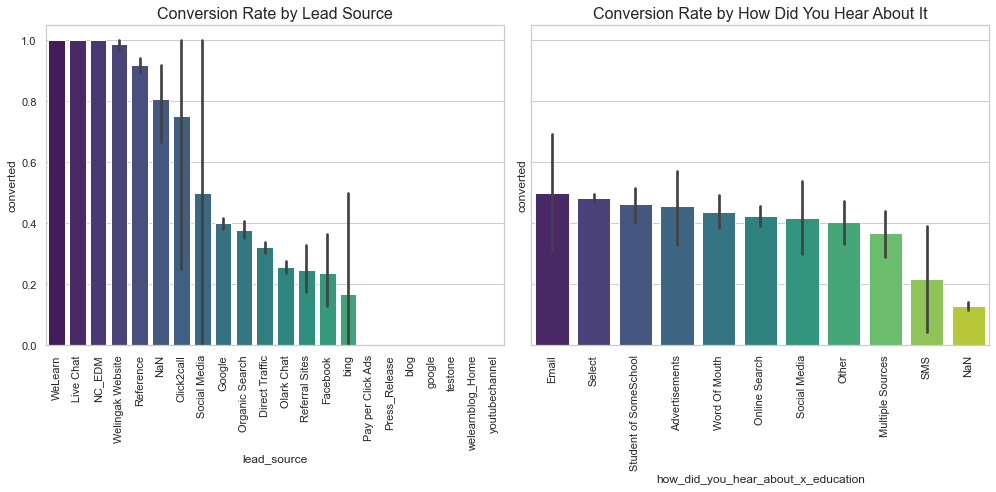

In [98]:
fig, ax  = plt.subplots(1,2, figsize=(14,7), sharey=True)

sns.barplot(data=df_.fillna('NaN'), x='lead_source', y='converted',
            order=order(df_.fillna('NaN'),'lead_source'),
            palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].set_title(f'Conversion Rate by Lead Source', loc='center', size=16)

sns.barplot(data=df_.fillna('NaN'), x='how_did_you_hear_about_x_education', y='converted',
                  order=order(df_.fillna('NaN'),'how_did_you_hear_about_x_education'),
                  palette='viridis', seed=2)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=90)
ax[1].set_title(f'Conversion Rate by How Did You Hear About It', loc='center', size=16)

plt.tight_layout()
plt.savefig('/Users/human1/Documents/HFU/DSResources/lead_source&hear_about_us.png', bbox_inches='tight')

plt.show()

## 3.7: Numerical Values Analysis

In [ ]:
df_.select_dtypes(include=['number'])

#This gives all the features with numerical values


In [99]:
#We have 21 numerical columns
print(df_.select_dtypes(include=['number']).shape)

(9240, 23)


Data Manipulation:
Almost all the numerical columns in the dataset represent binary outputs. But here's the catch: the vast majority of these columns have only one value, which is 0. That means they don't really offer any meaningful information to the model, and they're just cluttering up the dataset. Thus, it would be wise to drop these columns to improve model performance and reduce unnecessary noise in the data.

## 3.8: Time spent on page

FileNotFoundError: [Errno 2] No such file or directory: '/Users/human1/Documents/HFU/DSResources/all_activities.png'

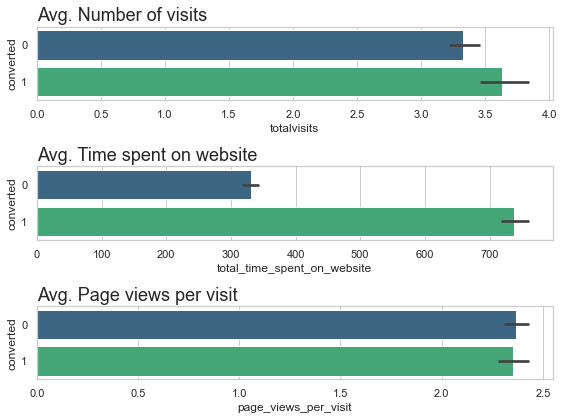

In [100]:
fig, ax  = plt.subplots(3, figsize=(8,6))
sns.barplot(data=df_, x='totalvisits', y='converted',
            orient='h', palette='viridis',
            seed=2, ax=ax[0])
ax[0].set_title(f'Avg. Number of visits', loc='left', size=18)

sns.barplot(data=df_, x='total_time_spent_on_website', y='converted',
            orient='h', palette='viridis',
            seed=2, ax=ax[1])
ax[1].set_title(f'Avg. Time spent on website', loc='left', size=18)

sns.barplot(data=df_, x='page_views_per_visit', y='converted',
            orient='h', palette='viridis',
            seed=2, ax=ax[2])
ax[2].set_title(f'Avg. Page views per visit', loc='left', size=18)

plt.tight_layout()
plt.savefig('/Users/human1/Documents/HFU/DSResources/all_activities.png', bbox_inches='tight')

plt.show()

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(8,6))
sns.boxplot(data=df_, x='totalvisits',
              ax=ax[0], palette='viridis')
ax[0].set_title('Total Visits', loc='left', size=16)

sns.boxplot(data=df_, x='total_time_spent_on_website',
              ax=ax[1], palette='viridis')
ax[1].set_title('Time spent on web', loc='left', size=16)

sns.boxplot(data=df_, x='page_views_per_visit',
              ax=ax[2], palette='viridis')
ax[2].set_title('Page views per visit', loc='left', size=16)

plt.tight_layout()
plt.savefig('/Users/human1/Documents/HFU/DSResources/visits_box_plot.png', bbox_inches='tight')

plt.show()


###KNN Imputation for numerical values

How it works:
For each missing value:

It identifies the K most similar rows (neighbors) that don’t have missing values in that column.

It estimates the missing value by averaging (or using a weighted average of) the corresponding values from these neighbors.


## 3.9: Feature Engineering

In [101]:
# Filter numeric features except the target
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [102]:
numerical_columns = [
    'Lead Number',
    'Converted',
    'TotalVisits',
    'Total Time Spent on Website',
    'Page Views Per Visit',
    'Asymmetrique Activity Index',
    'Asymmetrique Profile Index',
    'Asymmetrique Activity Score',
    'Asymmetrique Profile Score'
]

categorical_columns = [
    'Prospect ID',
    'Lead Origin',
    'Lead Source',
    'Do Not Email',
    'Do Not Call',
    'Last Activity',
    'Country',
    'Specialization',
    'How did you hear about X Education',
    'What is your current occupation',
    'What matters most to you in choosing a course',
    'Search',
    'Magazine',
    'Newspaper Article',
    'X Education Forums',
    'Newspaper',
    'Digital Advertisement',
    'Through Recommendations',
    'Receive More Updates About Our Courses',
    'Tags',
    'Lead Quality',
    'Update me on Supply Chain Content',
    'Get updates on DM Content',
    'Lead Profile',
    'City',
    'I agree to pay the amount through cheque',
    'A free copy of Mastering The Interview',
    'Last Notable Activity'
]


### 3.9.1: Data Cleaning

### 3.9.2: Intial Feature Engineering

### 3.9.3: Exploratory Data Analysis

### 3.9.4: Outliers Handling

In [103]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import FunctionTransformer

## Data Cleaning

def data_cleaning(df):
    df = df.copy()
    
    # Drop ID columns if they exist
    for col in ['Prospect ID', 'Lead Number']:
        if col in df.columns:
            df = df.drop(col, axis=1)
    
    # Define binary categorical columns - make sure this list is defined before
    # e.g. binary_cats = ['some_binary_col1', 'some_binary_col2']
    if 'binary_cats' in globals():
        for col in binary_cats:
            if col in df.columns:
                df[col] = df[col].map(lambda x: 0 if x == 'No' else 1)
    
    # Rename columns for easier handling
    df.columns = df.columns.str.replace(' ', '_').str.lower()
    
    return df

# Wrap the function as transformer
initial_clean = FunctionTransformer(data_cleaning)

# Example of usage:
# df_clean = initial_clean.fit_transform(df)


#------------------- Initial Feature Engineering -------------------
def initial_feature_engineering(df):
    df = df.copy()
    
    # Lead Source
    df['Lead Source'] = df['Lead Source'].str.replace('|'.join(['google', 'Pay per Click Ads']), 'Google', regex=True)
    df['Lead Source'] = df['Lead Source'].apply(lambda x: "Referral Sites" if 'blog' in str(x).lower() else x)
    df['Lead Source'] = df['Lead Source'].str.replace('Live Chat', 'Olark Chat')
    df['Lead Source'] = df['Lead Source'].str.replace('bing', 'Organic Search')
    top_sources = df['Lead Source'].value_counts()[:8].index
    df['Lead Source'] = df['Lead Source'].apply(lambda x: "Other" if x not in top_sources else x)

    # Last Activity and Last Notable Activity
    activity = ['Last Activity', 'Last Notable Activity']
    for col in activity:
        df[col] = df[col].str.replace('|'.join(['Email Received', 'SMS Sent']), 'SMS/Email Sent', regex=True)
        df[col] = df[col].str.replace('|'.join(['Email Marked Spam', 'Email Bounced', 'Unsubscribed']), 'Not interested in email', regex=True)
        df[col] = df[col].str.replace('Resubscribed to emails', 'Email Opened')
        df[col] = df[col].str.replace('|'.join(['Visited Booth in Tradeshow', 'View in browser link Clicked']), 'Page Visited on Website', regex=True)

    # Country
    df['Country'] = df['Country'].apply(lambda x: np.nan if str(x).lower() in ['unknown', 'asia/pacific region'] else x)

    # Specialization
    df['Specialization'] = df['Specialization'].str.replace('|'.join(['E-COMMERCE', 'E-Business']), 'E-commerce', regex=True)
    df['Specialization'] = df['Specialization'].str.replace('Banking, Investment And Insurance', 'Finance Management')
    df['Specialization'] = df['Specialization'].str.replace('Media and Advertising', 'Marketing Management')
    df['Specialization'] = df['Specialization'].str.replace('Select', 'Not Provided')

    # How did you hear about X Education
    df['How did you hear about X Education'] = df['How did you hear about X Education'].str.replace('Select', 'Not Provided')
    df['How did you hear about X Education'] = df['How did you hear about X Education'].str.replace('|'.join(['SMS', 'Email']), 'SMS/Email', regex=True)

    # What matters most to you in choosing a course
    df['What matters most to you in choosing a course'] = df['What matters most to you in choosing a course'].str.replace('|'.join(['Flexibility & Convenience', 'Other']), "Better Career Prospects", regex=True)

    # Lead Profile
    df['Lead Profile'] = df['Lead Profile'].str.replace('Select', 'Not Assigned')

    # City
    df['City'] = df['City'].str.replace('Select', 'Not Provided')

    return df

# ------------------- EDA Feature Engineering -------------------
def eda_feature_engineering(df):
    df = df.copy()

    # Tags column
    df['Tags'] = df['Tags'].str.replace('|'.join(['invalid number', 'wrong number given', 'number not provided']), 'Not interest in calls', regex=True)
    df['Tags'] = df['Tags'].str.replace('|'.join(["In confusion whether part time or DLP", "Interested in Next batch", "Shall take in the next coming month", "Still Thinking"]), "Shows certain interest", regex=True)
    df['Tags'] = df['Tags'].str.replace("University not recognized", "Not elegible")
    df['Tags'] = df['Tags'].apply(lambda x: 'Not elegible' if pd.notnull(x) and 'holder' in x else x)
    df['Tags'] = df['Tags'].str.replace('|'.join(["Interested in other courses", "Interested  in full time MBA", "Not doing further education"]), "Doesn't show interest", regex=True)
    df['Tags'] = df['Tags'].str.replace('|'.join(["Ringing", "switched off"]), "Still no contact", regex=True)
    df['Tags'] = df['Tags'].str.replace('|'.join(["Want to take admission but has financial problems", "Graduation in progress"]), "Not elegible for the moment", regex=True)
    df['Tags'] = df['Tags'].apply(lambda x: 'Not elegible for the moment' if pd.notnull(x) and 'Recognition' in x else x)
    top_tags = df['Tags'].value_counts(dropna=False)[:12].index
    df['Tags'] = df['Tags'].apply(lambda x: 'Other' if x not in top_tags else x)

    # Country and City
    indian_cities = ['Mumbai', 'Thane & Outskirts', 'Other Cities of Maharashtra', 'Tier II Cities']
    df.loc[(df['Country'] != 'India') & (df['City'].isin(indian_cities)), 'Country'] = 'India'
    top_countries = df[df['Country'] != 'Other']['Country'].value_counts()[:4].index
    df['Country'] = df['Country'].apply(lambda x: 'Other' if pd.notnull(x) and x not in top_countries else x)

    # Lead Quality
    df['Lead Quality'] = df['Lead Quality'].fillna('Not Sure')

    # Drop useless columns
    drop_cols = [
        'Magazine', 'Receive More Updates About Our Courses',
        'Update me on Supply Chain Content', 'Get updates on DM Content',
        'I agree to pay the amount through cheque'
    ]
    df = df.drop(columns=drop_cols, errors='ignore')

    # Add missing count feature
    df['amount_missing'] = df.isnull().sum(axis=1)

    return df

# ------------------- Outlier Capping -------------------
def cap_outliers(df):
    df = df.copy()
    num_cols = ['TotalVisits', 'Page Views Per Visit', 'Total Time Spent on Website']
    for col in num_cols:
        if col in df.columns:
            cap = df[col].quantile(0.95)
            df[col] = df[col].apply(lambda x: min(x, cap))
    return df

# ------------------- Transformers -------------------
initial_feature_engineering_transformer = FunctionTransformer(initial_feature_engineering)
eda_feature_engineering_transformer = FunctionTransformer(eda_feature_engineering)
cap_outliers_transformer = FunctionTransformer(cap_outliers)

# ------------------- Column Transform -------------------
cat_columns = [
    'Lead Origin', 'Lead Source', 'Country', 'What is your current occupation',
    'What matters most to you in choosing a course', 'Tags', 'Lead Quality',
    'City', 'Last Notable Activity'
]

num_cols = [
    'TotalVisits', 'Page Views Per Visit', 'Total Time Spent on Website',
    'amount_missing', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index',
    'Asymmetrique Activity Score', 'Asymmetrique Profile Score','Converted'
]

impute_cons = SimpleImputer(strategy='constant', fill_value='Missing')
impute_knn = KNNImputer(n_neighbors=5)
ohe = OneHotEncoder(handle_unknown='ignore')
sc = StandardScaler()

pipe_cat = make_pipeline(impute_cons, ohe)
pipe_num = make_pipeline(impute_knn, sc)

impute_scale = make_column_transformer(
    (pipe_cat, cat_columns),
    (pipe_num, num_cols),
    remainder='drop'
)

# ------------------- Final Pipeline -------------------
pipe = make_pipeline(
    initial_feature_engineering_transformer,
    eda_feature_engineering_transformer,
    cap_outliers_transformer,
    impute_scale
)
pipe

Pipeline(steps=[('functiontransformer-1',
                 FunctionTransformer(func=<function initial_feature_engineering at 0x7ff13068fc10>)),
                ('functiontransformer-2',
                 FunctionTransformer(func=<function eda_feature_engineering at 0x7ff162f0e310>)),
                ('functiontransformer-3',
                 FunctionTransformer(func=<function cap_outliers at 0x7ff162f0e430>)),
                ('columntransformer',
                 ColumnTransfor...
                                                   'Tags', 'Lead Quality',
                                                   'City',
                                                   'Last Notable Activity']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('knnimputer',
                                                                   KNNImputer()),
                                                                  ('standar

## 3.10: Final Data Processing 

In [104]:
df_preprocessed = pipe.fit_transform(df)

df_preprocessed.shape

df_transformed = pipe.fit_transform(df)  # this returns a sparse matrix

df_dense = df_transformed.todense()      # convert sparse matrix to dense (numpy matrix)
df_array = np.array(df_dense)             # convert matrix to numpy array

# You can create a DataFrame if you want, but you will lose original column names since they get expanded by OneHotEncoder
df_final = pd.DataFrame(df_array)


In [105]:
df_final.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,65,66,67,68,69,70,71,72,73,74
2710,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,-0.433108,-0.712048,0.871338,0.891655,-0.24773,-0.925147,-0.257090,-0.756949,-0.791863
941,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-1.155592,-1.272994,-0.906301,-0.826392,-0.24773,1.418538,0.595387,0.572142,1.262845
6138,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.289377,0.970791,0.636841,0.032632,-0.24773,0.481064,0.254396,0.173415,1.262845
5907,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,-0.071865,0.409845,1.773395,0.032632,-0.24773,0.949801,-0.427586,0.837960,-0.791863
7611,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,-0.433108,-0.151101,-0.868479,0.318973,-0.24773,1.418538,-0.257090,1.236687,-0.791863


In [106]:
# 1. Fit the pipeline on the original DataFrame
pipe.fit(df)

# 2. Get one-hot encoded column names from the OneHotEncoder
# Access the OneHotEncoder inside the categorical pipeline
ohe = pipe.named_steps['columntransformer'].transformers_[0][1].named_steps['onehotencoder']
ohe_feature_names = ohe.get_feature_names_out(cat_columns)

# 3. Combine with the numerical column names
# These are preserved after scaling, so we just use num_cols directly
final_columns = np.concatenate([ohe_feature_names, num_cols])

# 4. Transform the data and convert to DataFrame
df_transformed = pipe.transform(df)

# Convert sparse matrix to dense if needed
if hasattr(df_transformed, "toarray"):
    df_transformed = df_transformed.toarray()

# 5. Create final DataFrame with proper column names
df_final = pd.DataFrame(df_transformed, columns=final_columns)

# Now you can inspect the data
df_final.sample(5)


AttributeError: 'OneHotEncoder' object has no attribute 'get_feature_names_out'

# 4: Final Processed Data - df_final

In [ ]:
#Processed Dataframe - df_final
df_final.shape

# 5: Modeling

## 5.1: Adarsh Raj Modeling

### 5.1.1 : Preparation of Metrics Function

In [53]:
from sklearn.model_selection import StratifiedKFold


# Use stratified fold for ensure that we shuffle the dataset and conserve classes
skfold = StratifiedKFold(5, shuffle=True, random_state=12)

def display_scores(model,scores,pred):
    print(f'----------- {model.__class__.__name__}-----------')
    
    print(f'----------- {model} -----------')
    print('')
    print("------------------ Cross validation scores:")
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
    print('')
    print("--------------- Scores in the training set:")
    print("Precision:", precision_score(y_train,pred))
    print("Recall:", recall_score(y_train,pred))
    print("F1 score:", f1_score(y_train,pred))
    print("ROC - AUC score:", roc_auc_score(y_train,pred))
    # Confusion Matrix
    cf = confusion_matrix(y_train, pred, labels=model.classes_)
    print("\nConfusion Matrix (rows = Actual, columns = Predicted):")
    
    # Format it nicely
    cf_df = pd.DataFrame(cf, index=[f'Actual: {cls}' for cls in model.classes_],
                            columns=[f'Predicted: {cls}' for cls in model.classes_])
    print(cf_df)


    

### 5.1.2: Train Test Split

In [54]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import shap
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_final, test_size=.2, random_state=42, stratify=df_final['Converted'])
print(f'train shape: {train.shape}')
print(f'test shape: {test.shape}')

KeyError: 'Converted'

In [52]:
pip install --upgrade typing_extensions


     |████████████████████████████████| 43 kB 3.0 MB/s eta 0:00:011
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 3.10.0.2
    Uninstalling typing-extensions-3.10.0.2:
      Successfully uninstalled typing-extensions-3.10.0.2
Note: you may need to restart the kernel to use updated packages.


In [318]:
y_train = train['Converted']
y_train.shape

(7392,)

### 5.1.2: Training XGB Classifier

In [319]:
y_train = train['Converted'].astype(int)
X_train_pp = train.drop('Converted', axis=1)

# Ensure X_train_pp_df is always a DataFrame, even if sparse matrix
if hasattr(X_train_pp, "toarray"):
    X_train_pp_df = pd.DataFrame(X_train_pp.toarray(), columns=feature_names)
else:
    X_train_pp_df = X_train_pp.copy()


from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

xgb = XGBClassifier(random_state=42)
xgb_scores = cross_val_score(xgb, X_train_pp, y_train,
                             cv=skfold, scoring='f1', verbose=3, n_jobs=-1)

xgb.fit(X_train_pp, y_train)
xgb_pred = xgb.predict(X_train_pp)

# Precision and recall curve
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

xgb_prec, xgb_recall, xgb_threshold = precision_recall_curve(
    y_train, xgb_pred, pos_label=xgb.classes_[1])
xgb_prdisplay = PrecisionRecallDisplay(precision=xgb_prec, recall=xgb_recall)
xgb_prdisplay.plot()

# Display scores
display_scores(xgb, xgb_scores, xgb_pred)

# SHAP input DataFrame info
print(X_train_pp_df.shape)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:615: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 598, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1580, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 603, in _wrap_evaluation_matrices
    train_dmatrix = create_dmatrix(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1065, in _create_d

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Prospect ID: object, Lead Origin: object, Lead Source: object, Do Not Email: object, Do Not Call: object, Last Activity: object, Country: object, Specialization: object, How did you hear about X Education: object, What is your current occupation: object, What matters most to you in choosing a course: object, Search: object, Magazine: object, Newspaper Article: object, X Education Forums: object, Newspaper: object, Digital Advertisement: object, Through Recommendations: object, Receive More Updates About Our Courses: object, Tags: object, Lead Quality: object, Update me on Supply Chain Content: object, Get updates on DM Content: object, Lead Profile: object, City: object, I agree to pay the amount through cheque: object, A free copy of Mastering The Interview: object, Last Notable Activity: object

### 5.1.3: Hyperparameter Tuning

In [320]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

xgb_params = {
    'n_estimators': randint(50, 500),          # Number of trees
    'max_depth': randint(3, 15),               # Max depth of trees
    'learning_rate': uniform(0.01, 0.3),       # Step size shrinkage
    'subsample': uniform(0.5, 0.5),            # Row subsampling ratio
    'colsample_bytree': uniform(0.5, 0.5),     # Feature subsampling
    'gamma': uniform(0, 5),                    # Min loss reduction for split
    'min_child_weight': randint(1, 10),        # Min sum hessian for split
    'reg_alpha': uniform(0, 1),                # L1 regularization
    'reg_lambda': uniform(0, 1),               # L2 regularization
    'scale_pos_weight': uniform(0.5, 2.5)      # Class imbalance handling
}


xgb_randomcv = RandomizedSearchCV(xgb, xgb_params, cv=skfold,
                                 scoring='f1',
                                 return_train_score = True,
                                 random_state = 10,
                                 n_iter=50, verbose=3, n_jobs=1)

xgb_randomcv.fit(X_train_pp, y_train)

print("--------------- XG Boost --------------")
print("Best Parameters: ", xgb_randomcv.best_params_)
print("Best Score: ", xgb_randomcv.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END colsample_bytree=0.8856603216333729, gamma=0.1037597467970075, learning_rate=0.20009447047788262, max_depth=14, min_child_weight=1, n_estimators=463, reg_alpha=0.19806286475962398, reg_lambda=0.7605307121989587, scale_pos_weight=0.9227770914063387, subsample=0.5441699070870052;, score=(train=nan, test=nan) total time=   0.0s
[CV 2/5] END colsample_bytree=0.8856603216333729, gamma=0.1037597467970075, learning_rate=0.20009447047788262, max_depth=14, min_child_weight=1, n_estimators=463, reg_alpha=0.19806286475962398, reg_lambda=0.7605307121989587, scale_pos_weight=0.9227770914063387, subsample=0.5441699070870052;, score=(train=nan, test=nan) total time=   0.0s
[CV 3/5] END colsample_bytree=0.8856603216333729, gamma=0.1037597467970075, learning_rate=0.20009447047788262, max_depth=14, min_child_weight=1, n_estimators=463, reg_alpha=0.19806286475962398, reg_lambda=0.7605307121989587, scale_pos_weight=0.92277709140633

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:615: FitFailedWarning:

Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 598, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1580, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 603, in _wrap_evaluation_matrices
    train_dmatrix = create_dmatrix(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1065, in _create_dmatrix
    return QuantileDMatrix(
  File "/opt/anaconda3/lib/python3.9/sit

[CV 3/5] END colsample_bytree=0.6163205313679396, gamma=2.782590939225278, learning_rate=0.1671432654815092, max_depth=5, min_child_weight=2, n_estimators=451, reg_alpha=0.8207037412633496, reg_lambda=0.13456300346431616, scale_pos_weight=2.0118154000903603, subsample=0.6415741380336557;, score=(train=nan, test=nan) total time=   0.0s
[CV 4/5] END colsample_bytree=0.6163205313679396, gamma=2.782590939225278, learning_rate=0.1671432654815092, max_depth=5, min_child_weight=2, n_estimators=451, reg_alpha=0.8207037412633496, reg_lambda=0.13456300346431616, scale_pos_weight=2.0118154000903603, subsample=0.6415741380336557;, score=(train=nan, test=nan) total time=   0.0s
[CV 5/5] END colsample_bytree=0.6163205313679396, gamma=2.782590939225278, learning_rate=0.1671432654815092, max_depth=5, min_child_weight=2, n_estimators=451, reg_alpha=0.8207037412633496, reg_lambda=0.13456300346431616, scale_pos_weight=2.0118154000903603, subsample=0.6415741380336557;, score=(train=nan, test=nan) total ti

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:615: FitFailedWarning:

Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 598, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1580, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 603, in _wrap_evaluation_matrices
    train_dmatrix = create_dmatrix(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1065, in _create_dmatrix
    return QuantileDMatrix(
  File "/opt/anaconda3/lib/python3.9/sit

[CV 1/5] END colsample_bytree=0.6777906945648521, gamma=0.1171604483671973, learning_rate=0.29053870633032575, max_depth=6, min_child_weight=8, n_estimators=195, reg_alpha=0.6031629758620348, reg_lambda=0.7810606172902821, scale_pos_weight=2.0393421900839233, subsample=0.5105825955860774;, score=(train=nan, test=nan) total time=   0.0s
[CV 2/5] END colsample_bytree=0.6777906945648521, gamma=0.1171604483671973, learning_rate=0.29053870633032575, max_depth=6, min_child_weight=8, n_estimators=195, reg_alpha=0.6031629758620348, reg_lambda=0.7810606172902821, scale_pos_weight=2.0393421900839233, subsample=0.5105825955860774;, score=(train=nan, test=nan) total time=   0.0s
[CV 3/5] END colsample_bytree=0.6777906945648521, gamma=0.1171604483671973, learning_rate=0.29053870633032575, max_depth=6, min_child_weight=8, n_estimators=195, reg_alpha=0.6031629758620348, reg_lambda=0.7810606172902821, scale_pos_weight=2.0393421900839233, subsample=0.5105825955860774;, score=(train=nan, test=nan) total

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:615: FitFailedWarning:

Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 598, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1580, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 603, in _wrap_evaluation_matrices
    train_dmatrix = create_dmatrix(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1065, in _create_dmatrix
    return QuantileDMatrix(
  File "/opt/anaconda3/lib/python3.9/sit

[CV 3/5] END colsample_bytree=0.6225906115297091, gamma=3.3129644492046224, learning_rate=0.11455156443045118, max_depth=10, min_child_weight=6, n_estimators=99, reg_alpha=0.9748124993966691, reg_lambda=0.6805743744444447, scale_pos_weight=0.9831343307161526, subsample=0.5233696135806976;, score=(train=nan, test=nan) total time=   0.0s
[CV 4/5] END colsample_bytree=0.6225906115297091, gamma=3.3129644492046224, learning_rate=0.11455156443045118, max_depth=10, min_child_weight=6, n_estimators=99, reg_alpha=0.9748124993966691, reg_lambda=0.6805743744444447, scale_pos_weight=0.9831343307161526, subsample=0.5233696135806976;, score=(train=nan, test=nan) total time=   0.0s
[CV 5/5] END colsample_bytree=0.6225906115297091, gamma=3.3129644492046224, learning_rate=0.11455156443045118, max_depth=10, min_child_weight=6, n_estimators=99, reg_alpha=0.9748124993966691, reg_lambda=0.6805743744444447, scale_pos_weight=0.9831343307161526, subsample=0.5233696135806976;, score=(train=nan, test=nan) total

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:615: FitFailedWarning:

Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 598, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1580, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 603, in _wrap_evaluation_matrices
    train_dmatrix = create_dmatrix(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1065, in _create_dmatrix
    return QuantileDMatrix(
  File "/opt/anaconda3/lib/python3.9/sit

[CV 5/5] END colsample_bytree=0.8077510585292704, gamma=4.434775442343052, learning_rate=0.1650367833461326, max_depth=12, min_child_weight=3, n_estimators=364, reg_alpha=0.9096625765865544, reg_lambda=0.4133046555645703, scale_pos_weight=1.8386717907293075, subsample=0.6713215627822633;, score=(train=nan, test=nan) total time=   0.0s
[CV 1/5] END colsample_bytree=0.56478838857163, gamma=3.3141087569999437, learning_rate=0.29070100059869486, max_depth=12, min_child_weight=8, n_estimators=332, reg_alpha=0.9031717397299215, reg_lambda=0.009769977119685747, scale_pos_weight=1.0645318166585869, subsample=0.5660275636359935;, score=(train=nan, test=nan) total time=   0.0s
[CV 2/5] END colsample_bytree=0.56478838857163, gamma=3.3141087569999437, learning_rate=0.29070100059869486, max_depth=12, min_child_weight=8, n_estimators=332, reg_alpha=0.9031717397299215, reg_lambda=0.009769977119685747, scale_pos_weight=1.0645318166585869, subsample=0.5660275636359935;, score=(train=nan, test=nan) tota

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:615: FitFailedWarning:

Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 598, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1580, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 603, in _wrap_evaluation_matrices
    train_dmatrix = create_dmatrix(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1065, in _create_dmatrix
    return QuantileDMatrix(
  File "/opt/anaconda3/lib/python3.9/sit

[CV 2/5] END colsample_bytree=0.6440727904969056, gamma=4.206993287509106, learning_rate=0.1429531261082042, max_depth=4, min_child_weight=8, n_estimators=332, reg_alpha=0.8132554341026034, reg_lambda=0.11452620850314188, scale_pos_weight=2.760955074534569, subsample=0.8871840560313158;, score=(train=nan, test=nan) total time=   0.0s
[CV 3/5] END colsample_bytree=0.6440727904969056, gamma=4.206993287509106, learning_rate=0.1429531261082042, max_depth=4, min_child_weight=8, n_estimators=332, reg_alpha=0.8132554341026034, reg_lambda=0.11452620850314188, scale_pos_weight=2.760955074534569, subsample=0.8871840560313158;, score=(train=nan, test=nan) total time=   0.0s
[CV 4/5] END colsample_bytree=0.6440727904969056, gamma=4.206993287509106, learning_rate=0.1429531261082042, max_depth=4, min_child_weight=8, n_estimators=332, reg_alpha=0.8132554341026034, reg_lambda=0.11452620850314188, scale_pos_weight=2.760955074534569, subsample=0.8871840560313158;, score=(train=nan, test=nan) total time=

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:615: FitFailedWarning:

Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 598, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1580, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 603, in _wrap_evaluation_matrices
    train_dmatrix = create_dmatrix(
  File "/opt/anaconda3/lib/python3.9/site-packages/xgboost/sklearn.py", line 1065, in _create_dmatrix
    return QuantileDMatrix(
  File "/opt/anaconda3/lib/python3.9/sit

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Prospect ID: object, Lead Origin: object, Lead Source: object, Do Not Email: object, Do Not Call: object, Last Activity: object, Country: object, Specialization: object, How did you hear about X Education: object, What is your current occupation: object, What matters most to you in choosing a course: object, Search: object, Magazine: object, Newspaper Article: object, X Education Forums: object, Newspaper: object, Digital Advertisement: object, Through Recommendations: object, Receive More Updates About Our Courses: object, Tags: object, Lead Quality: object, Update me on Supply Chain Content: object, Get updates on DM Content: object, Lead Profile: object, City: object, I agree to pay the amount through cheque: object, A free copy of Mastering The Interview: object, Last Notable Activity: object

In [321]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import pandas as pd

def my_confusion_matrix(y_true, y_pred, model, y_proba=None, save_fig=False, fig_name="roc_curve.png"):
    # Confusion Matrix
    cf = confusion_matrix(y_true, y_pred, labels=model.classes_)
    print("\nConfusion Matrix (rows = Actual, columns = Predicted):")
    
    # Format it nicely
    cf_df = pd.DataFrame(cf, index=[f'Actual: {cls}' for cls in model.classes_],
                            columns=[f'Predicted: {cls}' for cls in model.classes_])
    print(cf_df)

    # If probabilities are provided, plot ROC Curve
    if y_proba is not None:
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8,6))
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)

        if save_fig:
            plt.savefig(fig_name, dpi=300, bbox_inches='tight')
            print(f"ROC curve saved as {fig_name}")

        plt.show()


### 5.1.4: Preparing test data

In [322]:
y_test = test['Converted'].astype(int)
X_test = test.drop('Converted', axis=1)



# Ensure X_test_pp_df is always a DataFrame, even if X_test is sparse
if hasattr(X_test, "toarray"):
    X_test_pp_df = pd.DataFrame(X_test.toarray(), columns=feature_names)
else:
    X_test_pp_df = X_test.copy()

# Preview the first row of the test set as a NumPy array
print(X_test.shape)


(1848, 36)


### 5.1.4: Testing Optimized XGB Model

In [207]:
X_test_pp=X_test.copy()


xgb_pred_test = xgb_randomcv.predict(X_test_pp)
y_proba = xgb_randomcv.predict_proba(X_test_pp)[:, 1]

print('Optimised Model : XGB')

print("Precision:", precision_score(y_test,xgb_pred_test))
print("Recall:", recall_score(y_test,xgb_pred_test))
print("F1 score:", f1_score(y_test,xgb_pred_test))
print("ROC - AUC score:", roc_auc_score(y_test,xgb_pred_test))
my_confusion_matrix(y_test, xgb_pred_test, xgb_randomcv, y_proba=y_proba, save_fig=True, fig_name="/Users/human1/Documents/HFU/DSResources/XGB_optmised.png")



NameError: name 'xgb_randomcv' is not defined

### 5.1.5: Testing Base XGB Model

In [208]:
xgb_pred_test_base = xgb.predict(X_test_pp)

y_proba = xgb_randomcv.predict_proba(X_test_pp)[:, 1]

print('Base Model : XGB')

print("Precision:", precision_score(y_test,xgb_pred_test_base))
print("Recall:", recall_score(y_test,xgb_pred_test_base))
print("F1 score:", f1_score(y_test,xgb_pred_test_base))
print("ROC - AUC score:", roc_auc_score(y_test,xgb_pred_test_base))
my_confusion_matrix(y_test, xgb_pred_test_base, xgb, y_proba=y_proba, save_fig=True, fig_name="/Users/human1/Documents/HFU/DSResources/XGB_base.png")



NotFittedError: need to call fit or load_model beforehand

### 5.1.6: Comparison of Precision, Recall, F1 Score, ROC-AUC 

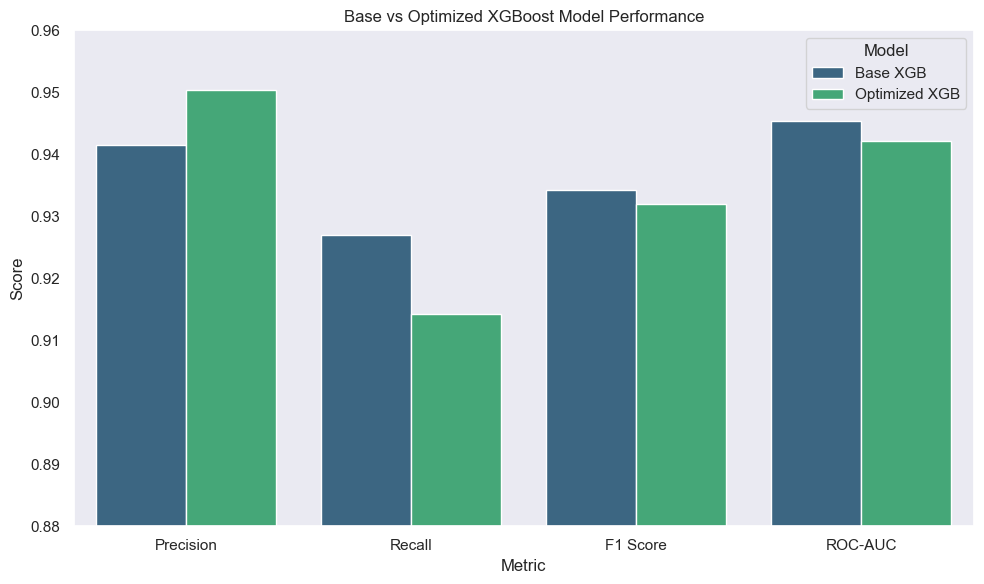

In [1028]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Metrics for each model
metrics = ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
base_scores = [0.9415, 0.9270, 0.9342, 0.9454]
opt_scores = [0.9504, 0.9143, 0.9320, 0.9422]

# Create DataFrame
df_plot = pd.DataFrame({
    'Metric': metrics * 2,
    'Score': base_scores + opt_scores,
    'Model': ['Base XGB'] * 4 + ['Optimized XGB'] * 4
})

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Model', palette='viridis')

plt.title('Base vs Optimized XGBoost Model Performance')
plt.ylim(0.88, 0.96)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.legend(title='Model')
plt.tight_layout()
plt.show()


### 5.1.7: Comparison of Confusion Matrix

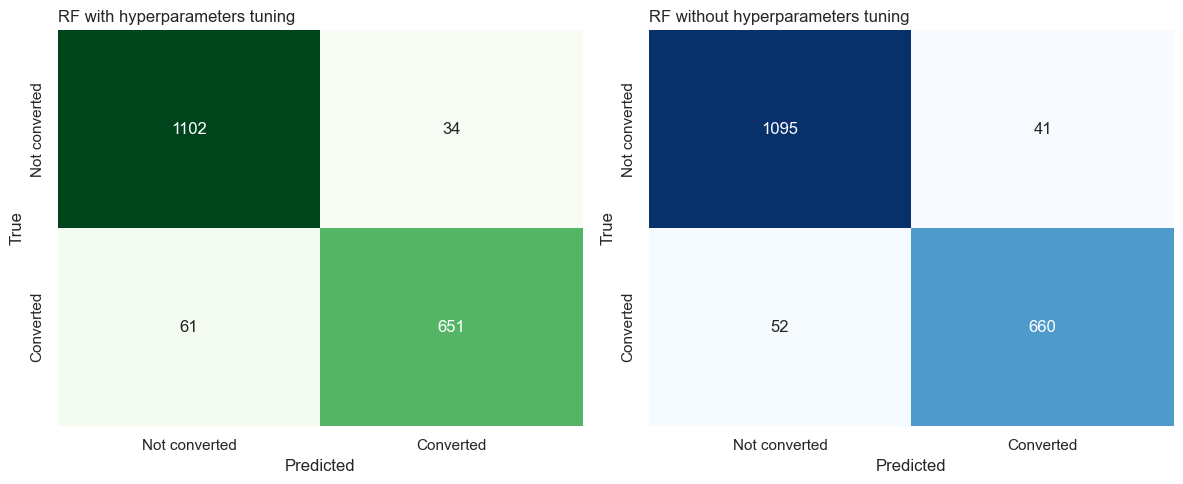

In [1031]:
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# XGB  tunned
cm1 = confusion_matrix(y_test, xgb_pred_test)
sns.heatmap(cm1, annot=True, fmt = 'd', cmap='Greens', ax = ax[0], cbar=False)
ax[0].xaxis.set_ticklabels(['Not converted', 'Converted'])
ax[0].yaxis.set_ticklabels(['Not converted', 'Converted'])
ax[0].set_title('RF with hyperparameters tuning', loc='left')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

# XGB without tuning
cm2 = confusion_matrix(y_test, xgb_pred_test_base)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', ax=ax[1], cbar=False)
ax[1].xaxis.set_ticklabels(['Not converted', 'Converted'])
ax[1].yaxis.set_ticklabels(['Not converted', 'Converted'])
ax[1].set_title('RF without hyperparameters tuning', loc='left')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('/Users/human1/Documents/HFU/DSResources/RFModel.png',bbox_inches='tight' )
plt.show()

### 5.1.8: Shap Analysis and Feature Importance

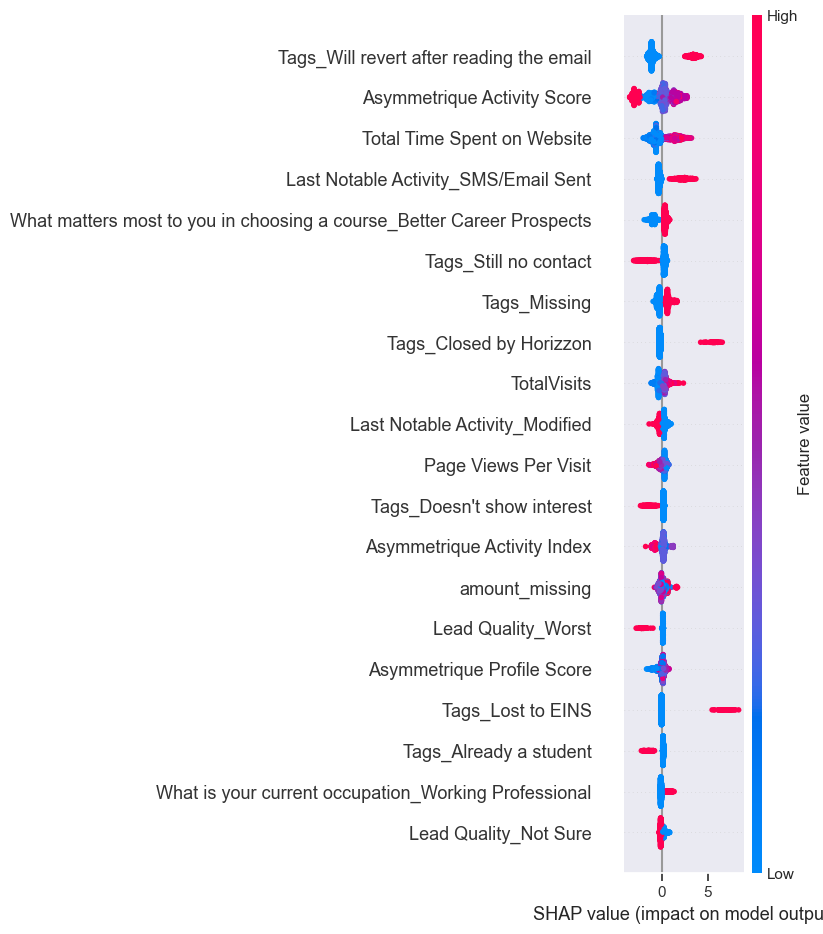

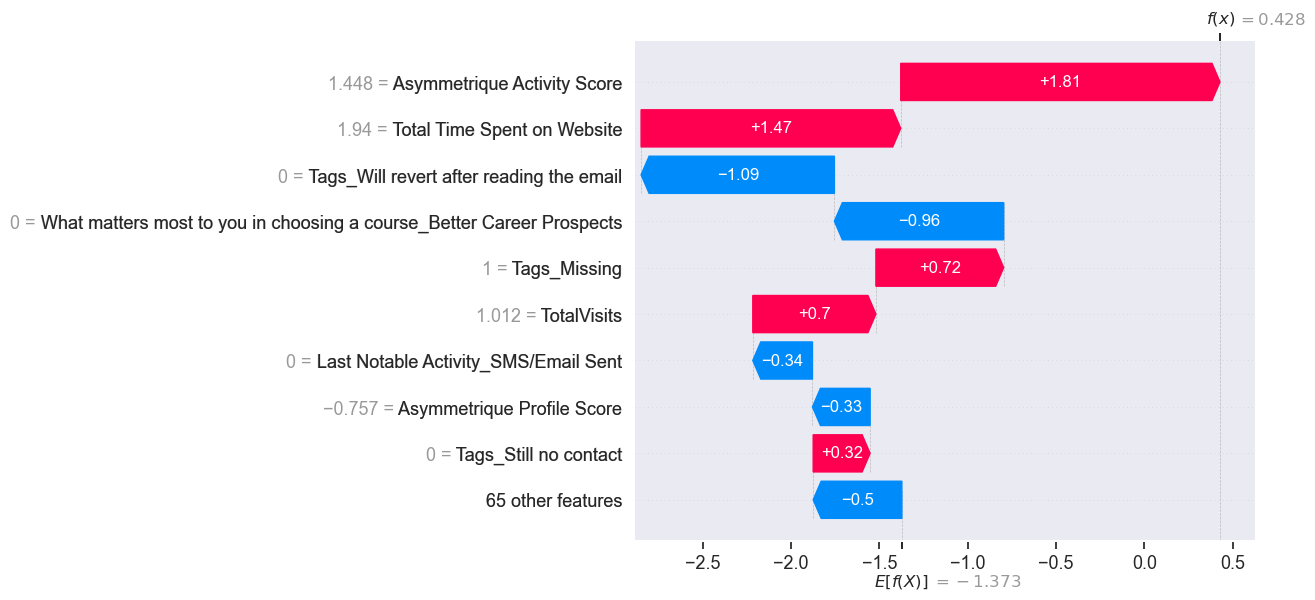

In [1034]:
import shap

# Initialize the TreeExplainer
explainer = shap.Explainer(xgb, X_train_pp_df)

# Compute SHAP values for the test set
shap_values = explainer(X_test_pp_df)

# Summary plot (global explanation)
shap.summary_plot(shap_values, X_test_pp_df)

# Choose an individual prediction to explain
index_to_explain = 0  # can be changed
shap.plots.waterfall(shap_values[index_to_explain])

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[index_to_explain].values, X_test_pp_df.iloc[index_to_explain])


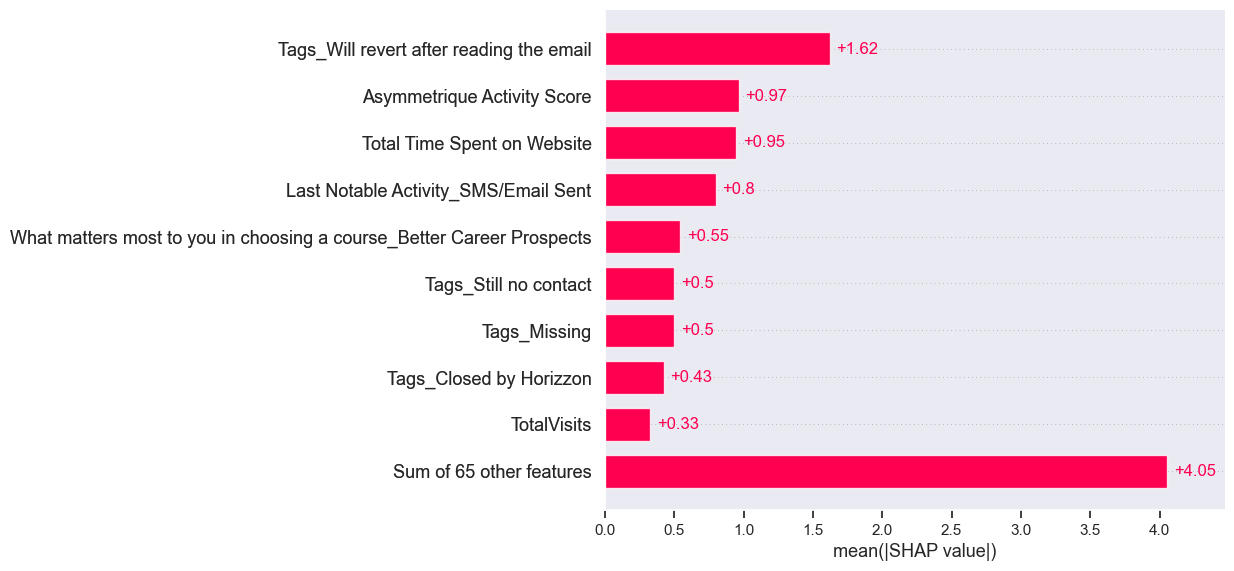

In [1035]:
# ✅ 2. SHAP Bar Plot - average absolute SHAP value
shap.plots.bar(shap_values)


## 5.2: Anjali Modeling

In [1039]:
#for training use below dataset
# X_train_pp, y_train


In [ ]:
#for testing use below dataset
#X_test, y_test


## 5.3: Tzu-Ching Lee Modeling

In [136]:
#Separate features (X) and target (y)
df.columns = df.columns.str.strip().str.lower()
df.drop(['prospect id', 'lead number'], axis=1, inplace=True)
X = df.drop('converted', axis=1)
y = df['converted']

In [111]:
#Identify numerical and categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [112]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [113]:
# For numeric columns: impute missing with median, then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

# For categorical columns: fill missing with 'missing', then OneHotEncode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

# Combine pipelines into a column transformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)])

pipe = Pipeline([
    ('preprocessor', preprocessor)])

In [117]:
#Split data and apply preprocessing

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train_pp = pipe.fit_transform(X_train)

In [118]:
#Train and evaluate Logistic Regression model

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

In [119]:
skfold = StratifiedKFold(n_splits=5)

In [120]:
lr = LogisticRegression(max_iter=5000)
lr_scores = cross_val_score(lr, X_train_pp, y_train, cv=skfold, scoring='f1')

lr.fit(X_train_pp, y_train)
lr_pred = lr.predict(X_train_pp)

=== Logistic Regression Evaluation (Train Set) ===
Cross-Validated F1 Score: 0.9204582359937075
Accuracy: 0.948051948051948
Precision: 0.9460731089395584
Recall: 0.9175149175149175
F1 Score: 0.9315751960085531
ROC-AUC: 0.9423586033755526

Confusion Matrix:
 [[4394  149]
 [ 235 2614]]


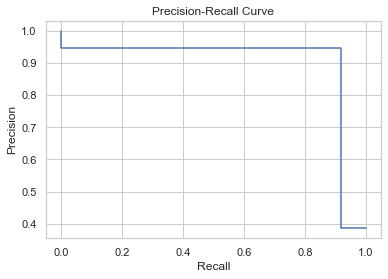

In [135]:
#Model evaluation results

print("=== Logistic Regression Evaluation (Train Set) ===")
print("Cross-Validated F1 Score:", lr_scores.mean())
print("Accuracy:", accuracy_score(y_train, lr_pred))
print("Precision:", precision_score(y_train, lr_pred))
print("Recall:", recall_score(y_train, lr_pred))
print("F1 Score:", f1_score(y_train, lr_pred))
print("ROC-AUC:", roc_auc_score(y_train, lr_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, lr_pred))


#Plot Precision-Recall Curve

lr_prec, lr_recall, _ = precision_recall_curve(y_train, lr_pred, pos_label=lr.classes_[1])
lr_prdisplay = PrecisionRecallDisplay(precision=lr_prec, recall=lr_recall)
lr_prdisplay.plot()
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [123]:
#Perform hyperparameter tuning

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

lr_params = {
    'C': uniform(loc=0, scale=4),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']}


In [124]:
lr_randomcv = RandomizedSearchCV(
    LogisticRegression(max_iter=5000),
    lr_params,
    cv=skfold,
    scoring='f1',
    return_train_score=True,
    random_state=10,
    n_iter=100)

In [125]:
lr_randomcv.fit(X_train_pp, y_train)

print("\n=== RandomizedSearchCV: Logistic Regression Tuning ===")
print("Best Parameters:", lr_randomcv.best_params_)
print("Best F1 Score:", lr_randomcv.best_score_)


=== RandomizedSearchCV: Logistic Regression Tuning ===
Best Parameters: {'C': 1.758420951098362, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 Score: 0.9253722561066123


In [132]:

# ===== Evaluate Logistic Regression on Test Data =====

X_test_pp = pipe.transform(X_test)
y_test_pred = lr.predict(X_test_pp)

=== Logistic Regression Evaluation (Test Set) ===
Accuracy: 0.9366883116883117
Precision: 0.9330422125181951
Recall: 0.9002808988764045
F1 Score: 0.9163688348820587
ROC-AUC: 0.9298939705649627
Confusion Matrix:
 [[1090   46]
 [  71  641]]


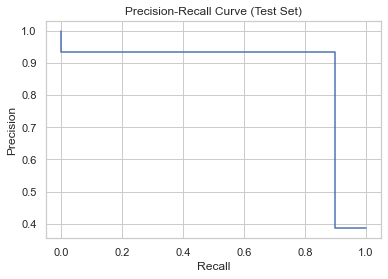

In [133]:
#Model Evaluation Test Set
print("=== Logistic Regression Evaluation (Test Set) ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

#Plot Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_test_pred, pos_label=lr.classes_[1])
disp = PrecisionRecallDisplay(precision=prec, recall=rec)
disp.plot()
plt.title("Precision-Recall Curve (Test Set)")
plt.grid(True)
plt.show()



=== Final Logistic Regression Evaluation (Test Set) ===
Accuracy: 0.9356060606060606
Precision: 0.9315866084425036
Recall: 0.898876404494382
F1 Score: 0.9149392423159399
ROC-AUC: 0.9287515825288811
Confusion Matrix:
 [[1089   47]
 [  72  640]]


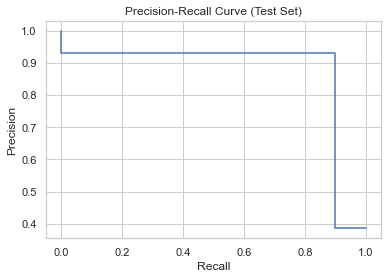

In [137]:

# === Final Evaluation on Test Set ===

#Construct the final model based on the optimal parameters.
final_model = LogisticRegression(max_iter=5000, **lr_randomcv.best_params_)
final_model.fit(X_train_pp, y_train)

#Make predictions on the test data
y_test_pred = final_model.predict(X_test_pp)

#Evaluation on the test set
print("\n=== Final Logistic Regression Evaluation (Test Set) ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

# Precision-Recall Curve
test_prec, test_rec, _ = precision_recall_curve(y_test, y_test_pred, pos_label=final_model.classes_[1])
test_disp = PrecisionRecallDisplay(precision=test_prec, recall=test_rec)
test_disp.plot()
plt.title("Precision-Recall Curve (Test Set)")
plt.grid(True)
plt.show()
